In [2]:
# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

from decimal import Decimal, ROUND_CEILING, ROUND_HALF_UP, getcontext # Besonders für sig. Runden
import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
import scipy.constants as cc
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
import scipy.integrate as integrate
from scipy.special import gamma

%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path
from pathlib import Path

import pandas as pd # Auch wichtig für den Latex Export
from pytexit import py2tex
import csv
import re
from typing import List


# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

# Display und Output
from IPython.display import display, Math, Latex, HTML

import textwrap 

# Grafiken in EU-Größen ausgeben
def figsize_cm(width_cm, height_cm):
    return (2*width_cm / 2.54, 2*height_cm / 2.54)
def comma_to_float(valstr):
    return float(valstr.replace(',','.'))

g=9.80984 
Delta_g=0.00002


In [ ]:
# 3 ResFreq Messungen 
# 2 mal Zeit zwischen Messungen zum Einstellen der Frequenz 2*t=2*?
# pro 3 Messungen n Messpunkte mit 12s

# 10-20 Temperaturwerte -> 20 Werte bei 20 Grad
# Zeit

In [ ]:
def gaussian(x, A,mu, sig,c): #A: Flaeche der Gaussfunktion
    return A/(sqrt(2*pi)*sig)*exp(-(x-mu)**2/2/sig**2)+c

for ax,(pfad,info) in zip(axes.flatten(),peaks.items()):
    name = info[0]
    mu_start = info[1]

    angle,intensity= np.loadtxt(Messwerte_path/pfad, converters={0:comma_to_float, 1:comma_to_float},unpack=True)
    Delta_intensity=np.sqrt(intensity)

    ax.errorbar(angle,intensity,yerr=Delta_intensity,fmt='-',capsize=3,elinewidth=0.5,ecolor='black',label=f"{name}-spectrum")

    c_start = np.min(intensity)                          # Untergrundrauschen
    A_start =(np.max(intensity) - c_start)   * (0.1 * np.sqrt(2 * np.pi)) # Fläche rückwärts berechnet
    popt, pcov=curve_fit(gaussian,angle,intensity,p0=[A_start,mu_start,0.1,c_start],sigma=Delta_intensity,absolute_sigma=True)
    x=np.linspace(angle[0],angle[-1],100)
    ax.plot(x, gaussian(x,*popt), label='Gauss-Fit')

    FHWM=2*popt[2]*np.sqrt(2*np.log(2))
    mu_sig,Delta_mu_sig,_,latexmusig=round_to_sigs(popt[1],FHWM,r'\degree')
    ax.hlines(1/2*(gaussian(popt[1],*popt)-popt[3])+popt[3],xmin=popt[1]-FHWM/2,xmax=popt[1]+FHWM/2,linestyle='dotted',color='C1',label=r'FWHM$=\Delta \mu$')
    
    ax.set_xlabel(r'angle [°]')
    ax.set_ylabel(r'intensity [a.u.]')
    
    def deg_to_wavelength(deg,n):
        theta_rad = np.radians(deg)
        return 2 * d * np.sin(theta_rad)/n
    def wavelength_to_deg(wl,n):
    # Arcussinus abfangen, falls Werte außerhalb des Definitionsbereichs liegen
        with np.errstate(invalid='ignore'):
            return np.degrees(np.arcsin(n*wl / (2 * d)))
        
    n_ord = 1 if popt[1] < 15 else 2
    Lambda,Delta_lambda,_,latexlambda=round_to_sigs(1e12*deg_to_wavelength(popt[1],n_ord),1e12*(deg_to_wavelength(popt[1]+1/2*FHWM,n_ord)-deg_to_wavelength(popt[1]-1/2*FHWM,n_ord)),r'\pico\m')
    K.append(Lambda)
    Delta_K.append(Delta_lambda)
    ax.axvline(popt[1],linestyle='--',color='C1',label=rf'$\mu=({mu_sig}\pm{Delta_mu_sig})°$'+'\n'+rf'$\;\;\,=({Lambda}\pm{Delta_lambda})$ pm')
    fwd = lambda deg,n=n_ord: deg_to_wavelength(deg, n)
    inv = lambda wl,n=n_ord: wavelength_to_deg(wl, n)
    secax = ax.secondary_xaxis('top', functions=(fwd, inv))
    secax.set_xlabel(r'wavelength $\lambda$ [m]')
    ax.set_title(name+' spectrum')
    ax.legend() 
plt.tight_layout()
plt.savefig(Ausgabe_path/'Klines.png',format="png",bbox_inches='tight')
plt.show()

In [340]:
currentversuch = "255"
base = Path.cwd()                   
Messwerte_path = Path(base.parent.parent.parent/"Messwerte"/currentversuch)      # initializing paths
Ausgabe_path = Path(base/"Diagramme")
print(Messwerte_path)
print(Ausgabe_path)

c:\Users\samue\OneDrive\Dokumente\PAP\PAP2\Messwerte\255
c:\Users\samue\OneDrive\Dokumente\PAP\PAP2\Auswertungen2.2\Code\255\Diagramme


Delete UTF8 False encoding

In [6]:
# def deletevocals(text):
#     text=textwrap.dedent(text)
#     patterna = r'[¨][a]'
#     text=re.sub(patterna,"ä",text)
#     patternu=r'[¨][u]'
#     text=re.sub(patternu,"ü",text)
#     patterno=r'[¨][o]'
#     text=re.sub(patterno,"ö",text)
#     return text

# Regexwissen: [0-9], [A-Z] findet egal welchen Zahl/Buchstaben; [^0-9] findet erstes Zeichen, das keine Zahl ist; 

def deletevocals(text):
    # Einrückungen entfernen (gemeinsame Tabs des gesamten Textes)
    text = textwrap.dedent(text)
    #  entfernt Bindestriche: - findet Bindestrich, \n Zeilenumbruch direkt dahinter, \s Whitespaces *beliebig viele 
    text = re.sub(r'-\n\s*',"",text)
    # entfernt Zeilenumbrüche
    text = text.replace("\n"," ")
    
    # Eine Funktion, die vom re.sub aufgerufen wird, wenn ein Treffer erzielt wird
    def convert(match):
        # match.group(1) ist der Buchstabe nach dem Pünktchen (z.B. 'a' oder 'A')
        buchstabe = match.group(1)
        # Dictionary für die echten Umlaute
        umlaute = {'a': 'ä', 'u': 'ü', 'o': 'ö', 'A': 'Ä', 'U': 'Ü', 'O': 'Ö'}
        # Gib den Umlaut zurück. Falls das Zeichen nicht im Dict ist, lass es wie es ist
        return umlaute.get(buchstabe, buchstabe)
    # Das Pattern sucht nach ¨ gefolgt von einem beliebigen Buchstaben aus der Auswahl, [X] findet genau ein Zeichen aus Menge X
    return re.sub(r'¨([auoAUO])', convert, text)    

In [7]:
print(deletevocals("""

"""))

Runden signifikanter Stellen

In [343]:
def round_to_sigs(val,errVal=None,einheiten=None):
    """
    Funktion zur Rundung eines Fehlers und die Anpassung des Messwertes daran. Diese Funktion wurde etwas umständlicher 
    geschrieben, da python mit Floats und Runden schnell in Probleme rennt. Daher musste hier mit dezimal gearbeitet werden.
    Zudem sollten besonders kleine und große Messwerte in der Dezimalschreibweise geschrieben werden, damit diese auch 
    für Protokolle geiegnet sind.

    Parameter
    ----------
    **val** : float
        Messwert

    **errVal** : float
        Ungenauigkeit des Messwertes

    Return
    ------
    **value_rounded** : str
        Gerundeter Messwert

    **error_rounded** : str
        Gerundete Ungenauigkeit des Messwertes

    **res** : str
        "Messwert \\pm Fehler"
    """
    einheiten_str = einheiten if einheiten is not None else ""
    if errVal is not None:
        # Daten zu Dezimal wechseln, da Floats probleme machen
        val = Decimal(str(val))
        errVal = Decimal(str(errVal))

        exp = int(math.floor(math.log10(float(errVal))))            # Die erste signifikante Stellenposition wird anhand des errVal bestimmt

        if round(float(errVal / (Decimal(10) ** exp))) < 3:         # wenn 1,2,3 erste signifikante Stelle, dann kommt eine zweite Nachkommastellenposition hinzu
            exp -= 1

        scale = Decimal(10) ** exp                                  

        val_round = (val / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale            # mit scale wird das Komma so verschoben, dass alle signifikanten Stellen vor dem Komma stehen, und dann alle Nachkommastellen weggerundet werden
        err_round = (errVal / scale).quantize(Decimal('1'), rounding=ROUND_CEILING) * scale

        num = f"\\num{{{val_round}({err_round})}}"
        qty = f"\\qty{{{val_round}({err_round})}}{{{einheiten_str}}}" if einheiten else num

        return float(val_round), float(err_round), num, qty
    else:
        val = Decimal(str(val))
        exp = int(math.floor(math.log10(float(val))))
        if round(float(val / (Decimal(10) ** exp))) < 3:         # wenn 1,2,3 erste signifikante Stelle, dann kommt eine zweite Nachkommastellenposition hinzu
            exp -= 1
        scale = Decimal(10) ** exp   
        val_round = (val / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale
        num = f"\\num{{{val_round}}}"
        qty = f"\\qty{{{val_round}}}{{{einheiten_str}}}"if einheiten else num
    return float(val_round), None, num, qty

v_round = np.vectorize(round_to_sigs, otypes=[float, float, object, object], excluded=['einheiten'])

    # wissenschaftliche Notation erstmal vernachlässigen (da häufig Einheiten gewollt sind, die 10^/e Prefixe beinhalten)

Gausssche Fehlerfortpflanzung

In [344]:
def gff(function, errPronePar,latex=True):
    """
    Kann die Fehlerformel einer gegebenen Gleichung bestimmen.

    Parameters
    ----------
    **func** : sympy function
        Funktion dessen Fehler bestimmt werden soll.

    **errPronePar** : Array
        Liste (Array) aller fehlerbehafteten Größen der Gleichung con sp.Symbols
        Diese Werte werden als x_sym, y_sym, z_sym etc. bezeichnet und sind ungleich den Werten für x, y, z.
        Für die Werte wird daher die Bezeichnung x_val, y_val, z_val etc. genutzt und für deren Fehler err_x, err_y, err_z etc.

    Return
    ----------
    **absolut_err** : sympy function
        Gibt die Fehlergleichung des absoluten Fehlers wieder. 

    **relativ_err** : sympy function
        Gibt die Fehlergleichung des relativen Fehlers wieder. 
        
    **errProneParamters** : array
        Liste aller Fehlerbehafteten Größen
    """ 

    error = 0
    errProneParamaters = []

    function = sp.sympify(function)
    variables = errPronePar.split(",")
    variables = sp.symbols(variables)

    for variable in variables:
        Delta = sp.Symbol(f"Delta_{variable}")
        partial = sp.diff(function, variable)                   # Die Funktion wird nach der fehlerbehafteten Variable abgeleitet
        term=sp.UnevaluatedExpr(partial*Delta)**2
        error = error + ((term))                                # Fehler werden quadratisch aufsummiert
        errProneParamaters.append((variable,Delta))
    
    absolute_err=sp.simplify(sp.sqrt(error),rational = True)             
    relative_err=sp.simplify(sp.sqrt(error/function**2),rational = True)
    
    if latex:
        #Prints out the Latex Code for the Functions
        print("Funktion:")
        display(Math(sp.latex(function,long_frac_ratio=2))) 
        print(sp.latex(function))
        print("Absoluter Fehler:")
        display(Math(sp.latex(absolute_err,long_frac_ratio=2)))
        print(sp.latex(absolute_err))
        print("Relativer Fehler:")
        display(Math(sp.latex(relative_err,long_frac_ratio=2)))
        print(sp.latex(relative_err))
    return function,absolute_err, relative_err, errProneParamaters


Sigma-Abweichungen

In [345]:
def sigma_abweichung(p1, err_p1,p2,err_p2):
    """
    Funktion zum berechnen der Sigma-Abweichugn von zwei Messwerten, oder einem Messwert und einem Literaturwert.
    """
    if err_p1 == 0 and err_p2 == 0:
        raise ValueError("Für die Sigma-Abweichung muss mindestens ein Wert fehlerbehaftet sein!")
    else:
        abweichung=Decimal(str(abs(p1 - p2)/(np.sqrt(err_p1 ** 2+err_p2 ** 2))))

    if abweichung == 0:
        return 0.0, "\\num{0}"
    
    exp = int(math.floor(math.log10(float(abweichung))))
    if round(float(abweichung / (Decimal(10) ** exp))) < 3:         # wenn 1,2,3 erste signifikante Stelle, dann kommt eine zweite Nachkommastellenposition hinzu
        exp -= 1
    scale = Decimal(10) ** exp   
    abweichung_round = (abweichung / scale).quantize(Decimal('1'), rounding=ROUND_CEILING) * scale
    res = f"\\num{{{abweichung_round}}}"

    return float(abweichung_round),res



In [346]:

# #Größenvergleich in latex
# def size_comp_str(name1,name2,val1,val2):
#     if val1<val2:
#         return name1+"<"+name2
#     elif val1>val2:
#         return name1+">"+name2
#     else:
#         return name1+"="+name2
   
#Erstellung von Vergleichstabellen in Latex
def compare_table_array(nam1, nam2, einheiten, val1_array, err1_array, val2_array, err2_array):
    # 1. Tabellenkopf (Hier werden die Strings einmalig eingesetzt)
    output_header = textwrap.dedent(f"""
        \\begin{{table}}[htbp]
        \\centering
        \\caption{{Vergleich von ${nam1}$ und ${nam2}$}}
        \\begin{{tabularx}}{{0.8\\textwidth}}{{ZZZZZ}}
            \\toprule
                 Messreihe & {nam1}[\\unit{{{einheiten}}}] & {nam2}[\\unit{{{einheiten}}}] & \\text{{abs.Abw.}}[\\unit{{{einheiten}}}] & \\text{{proz.Abw.}}[\\unit{{\\percent}}] & S[\\sigma] \\\\\\midrule
    """).strip() # strip macht whitespaces am anfang und ende des strings weg
    
    table_rows = []

    # 2. Der Body (Schleife läuft über die Werte-Arrays)
    for val1, err1, val2, err2 in zip(val1_array, err1_array, val2_array, err2_array):
        
        VAL1=round_to_sigs(val1,err1,r'')[2]
        if err2!=0:
            VAL2=round_to_sigs(val2,err2,r'')[2]
        else:
            VAL2=val2

        abs=np.abs(val1-val2)
        abs_delta=np.sqrt(err1**2+err2**2)
        if abs_delta!=0:
            SIGMA=sigma_abweichung(val1,err1,val2,err2)[1]
        else:
            SIGMA=0.0

        rel=abs/np.abs(val1)*100
        if abs != 0:
            rel_delta = rel * np.sqrt((abs_delta / abs)**2 + (err1 / val1)**2)
            ABS = round_to_sigs(abs, abs_delta, r'')[2]
            REL = round_to_sigs(rel, rel_delta, r'')[2]
        else:
            rel_delta = 0
            ABS = "0"
            REL = "0"
        
        # Eine saubere Zeile nur mit den Werten für LaTeX
        row = f"        & {VAL1} & {VAL2} & {ABS} & {REL} & {SIGMA} \\\\"
        table_rows.append(row)
    
    body_str = "\n".join(table_rows)
    
    # 3. Tabellenfuß
    output_footer = textwrap.dedent(f"""
                \\bottomrule
        \\end{{tabularx}}
        \\label{{table:Vergleich_{nam1}}} 
        \\end{{table}}
    """).strip()
    
    # Alles zusammensetzen
    final_output = f"{output_header}\n{body_str}\n{output_footer}"
    
    print(final_output)


In [347]:
# #Erstellung von Vergleichstabellen in Latex
# def compare_table_withliterature(nam1,nam2,einheiten,val1,err1,val2):
#     VAL1=round_to_sigs(val1,err1,r'')[2]
#     abs=np.abs(val1-val2)
#     abs_delta=np.sqrt(err1**2)
#     if abs_delta!=0:
#         SIGMA=sigma_abweichung(val1,err1,val2,0)[1]
#     else:
#         SIGMA=0.0
#     ABS=round_to_sigs(abs,abs_delta,r'')[2]
#     rel=abs/np.abs(val2)*100
#     rel_delta=rel*np.sqrt((abs_delta/abs)**2+(err1/val1)**2) if abs != 0 else 0
#     REL=round_to_sigs(rel,rel_delta,r'')[2]
#     output = textwrap.dedent(f"""
#         \\begin{{table}}[htb]
#         \\centering
#         \\caption{{}}
#         \\begin{{tabularx}}{{0.8\\textwidth}}{{ZZZZZ}}
#             \\toprule
#                 {nam1}[\\unit{{{einheiten}}}]&{nam2}[\\unit{{{einheiten}}}]&\\text{{abs.Abw.}}[\\unit{{{einheiten}}}]&\\text{{proz.Abw.}}[\\unit{{\\percent}}]&S[\\sigma]\\\\\\midrule
#                 {VAL1}&\\num{{{val2}}}&{ABS}&{REL}&{SIGMA}\\\\
#             \\bottomrule
#         \\end{{tabularx}}
#         \\label{{table:Vergleich_{nam1}}} 
#         \\end{{table}}
#     """)
#     print(output)
    

    
# #Größenvergleich in latex
# def size_comp_str(name1,name2,val1,val2):
#     if val1<val2:
#         return name1+"<"+name2
#     elif val1>val2:
#         return name1+">"+name2
#     else:
#         return name1+"="+name2
   
#Erstellung von Vergleichstabellen in Latex
import textwrap 
def compare_table(nam1,nam2,einheiten,val1,err1,val2,err2):
    VAL1=round_to_sigs(val1,err1,r'')[2]
    if err2!=0:
        VAL2=round_to_sigs(val2,err2,r'')[2]
    else:
        VAL2=val2
    abs=np.abs(val1-val2)
    abs_delta=np.sqrt(err1**2+err2**2)
    if abs_delta!=0:
        SIGMA=sigma_abweichung(val1,err1,val2,err2)[1]
    else:
        SIGMA=0.0

    rel=abs/np.abs(val1)*100
    if abs != 0:
        rel_delta = rel * np.sqrt((abs_delta / abs)**2 + (err1 / val1)**2)
        ABS = round_to_sigs(abs, abs_delta, r'')[2]
        REL = round_to_sigs(rel, rel_delta, r'')[2]
    else:
        rel_delta = 0
        ABS = "0"
        REL = "0"

    output = textwrap.dedent(f"""
        \\begin{{table}}[htbp]
        \\centering
        \\caption{{Vergleich von ${nam1}$ und ${nam2}$}}
        \\begin{{tabularx}}{{\\textwidth}}{{ZZZZx}}
            \\toprule
                {nam1}[\\unit{{{einheiten}}}]&{nam2}[\\unit{{{einheiten}}}]&\\text{{abs.Abw.}}[\\unit{{{einheiten}}}]&\\text{{proz.Abw.}}[\\unit{{\\percent}}]&S[\\sigma]\\\\\\midrule
                {VAL1}&{VAL2}&{ABS}&{REL}&{SIGMA}\\\\
            \\bottomrule
        \\end{{tabularx}}
        \\label{{table:Vergleich_{nam1}}} 
        \\end{{table}}
    """)
    print(output)



\qty{4.9(1.0)}{\degree}


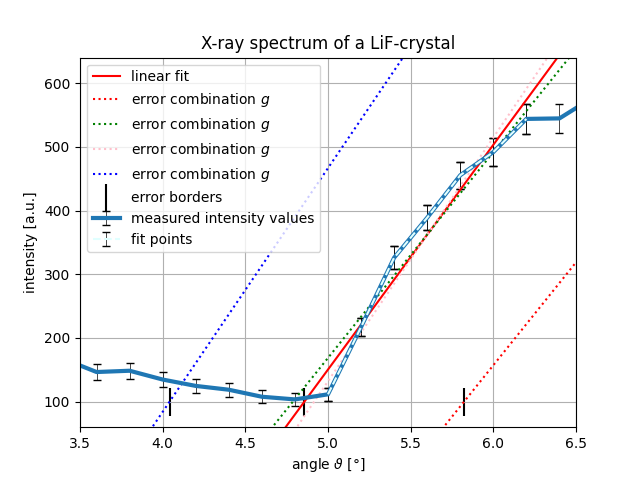

In [364]:
angle,intensity = np.loadtxt(Messwerte_path/"A1_30_06_2026_A1.txt", skiprows=1, converters={0:comma_to_float, 1:comma_to_float},unpack=True) # Intensität pro Winkel
Delta_intensity=np.sqrt(intensity)
def linear(x,m,a):
    return m*x+a
popt, pcov=curve_fit(linear, angle[10:17],intensity[10:17])
plt.close('all')

plt.errorbar(angle,intensity,yerr=Delta_intensity,fmt='-',linewidth=3,capsize=3,elinewidth=0.5,ecolor='black',label='measured intensity values')
plt.errorbar(angle[10:17],intensity[10:17],yerr=Delta_intensity[10:17],linestyle='dashed',color='lightcyan',ecolor='black',capsize=3,elinewidth=0.5,label='fit points')
plt.plot(x, linear(x,*popt),color='red',label='linear fit')

m_1=popt[0]-np.sqrt(pcov[0][0])
m_2=popt[0]+np.sqrt(pcov[0][0])
c_1=popt[1]-np.sqrt(pcov[1][1])
c_2=popt[1]+np.sqrt(pcov[1][1])
x=np.linspace(3.5,6.5,10)
plt.plot(x, linear(x,m_1,c_1),linestyle='dotted',color='red',label=r'error combination $g$')
plt.plot(x, linear(x,m_1,c_2),linestyle='dotted',color='green',label=r'error combination $g$')
plt.plot(x, linear(x,m_2,c_1),linestyle='dotted',color='pink',label=r'error combination $g$')
plt.plot(x, linear(x,m_2,c_2),linestyle='dotted',color='blue',label=r'error combination $g$')
points=[(100-c_1)/m_1,(100-c_2)/m_2,(100-popt[1])/popt[0]]
plt.scatter(points,[100,100,100],marker='|',s=400,color='black',label='error borders')
theta=points[2]
Delta_theta=np.max([np.abs(points[0]-points[2]),np.abs(points[2]-points[1])])
theta,Delta_theta,_,latexUa=round_to_sigs(theta,Delta_theta,r'\degree')
print(latexUa)

plt.xlabel(r'angle $\vartheta$ [°]')
plt.ylabel(r'intensity [a.u.]')
plt.title(r'X-ray spectrum of a LiF-crystal')
plt.xlim(3.5,6.5)
plt.ylim(60,640)
# plt.text(0.8, 0.2,rf'$E_R={E_R}({Delta_E_R})$keV', horizontalalignment='center',verticalalignment='center', transform=plt.gca().transAxes)
# plt.text(0.8, 0.1,rf'$\sigma_{{12}}={sigma}({Dxelta_sigma})$', horizontalalignment='center',verticalalignment='center', transform=plt.gca().transAxes)
plt.legend()
plt.grid()
plt.show()
plt.savefig(Ausgabe_path/"task1_LiFspectrumzoomed.png",format="png")

In [ ]:
critang,Delta_critang,_,latexcrit=round_to_sigs(np.radians(theta),np.radians(Delta_theta))
print(critang,Delta_critang)
n=1
d = 201.4*1e-12
critlambda = 2*d*critang / n
Delta_critlambda = 2*d*Delta_critang / n
critlambda,Delta_critlambda,_,latexLcr=round_to_sigs(critlambda,Delta_critlambda,r'\nano\m')
print(latexLcr)

U_a=35*1e3
Delta_U_a=0.05*1e3
h=U_a*cc.e*critlambda/cc.c
Delta_h=h*np.sqrt(Delta_U_a**2/U_a**2 + Delta_critlambda**2/critlambda**2)
h,Delta_h,_,latexh=round_to_sigs(h,Delta_h,r'\joule\s')
print(latexh)

n=2
theta_2=n*critlambda/(2*d)
Delta_theta_2=np.sqrt(Delta_critlambda**2*n**2/d**2)/2
theta_2,Delta_theta_2,_,latextheta_2=round_to_sigs(theta_2,Delta_theta_2,r'\radian')
_,_,_,latexTHETA_2=round_to_sigs(np.degrees(theta_2),np.degrees(Delta_theta_2),r'')
print(latextheta_2)
print(latexTHETA_2)

0.086 0.018
\qty{3.5E-11(8E-12)}{\nano\m}
\qty{6.5E-34(1.5E-34)}{\joule\s}
\qty{0.17(0.04)}{\radian}
\num{9.7(2.3)}
0.15707963267948966
0.15643446504023087


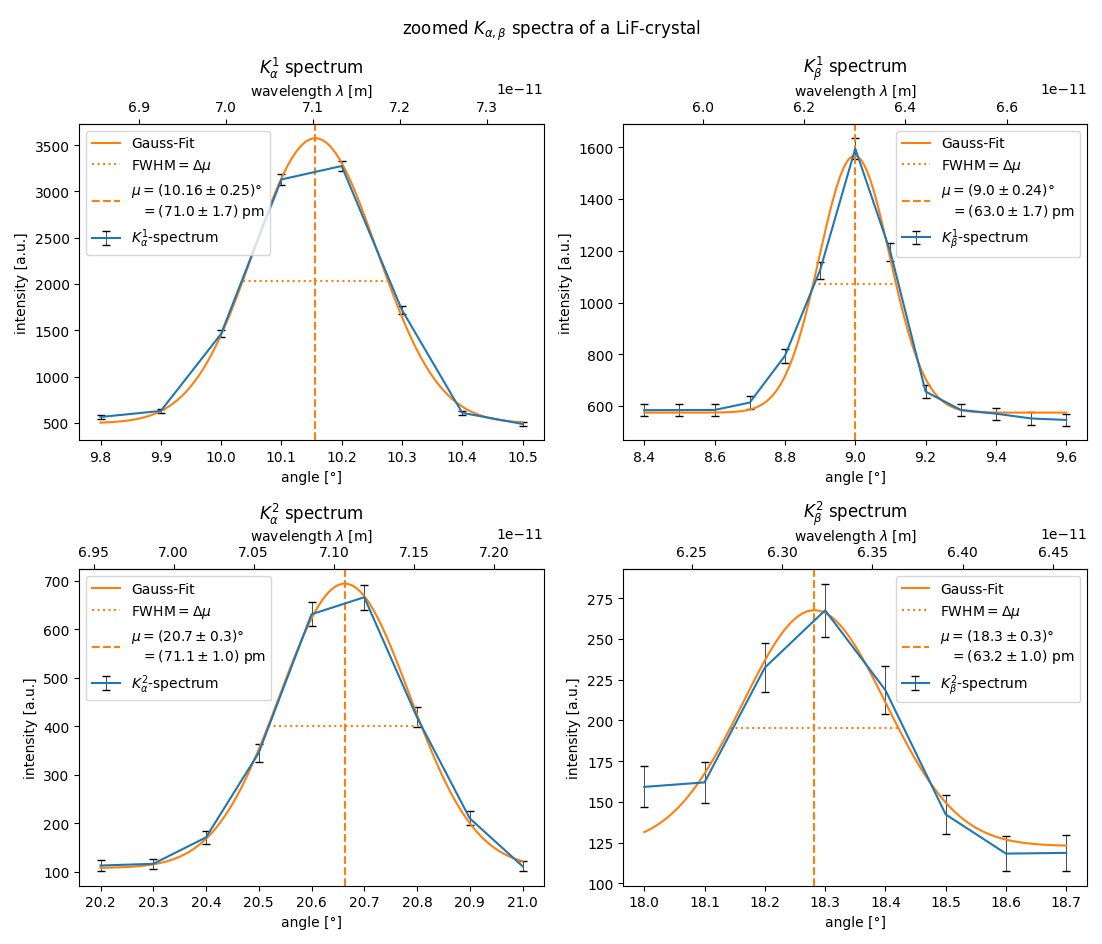

In [362]:
peaks={"A2_Ka1_30_06_2026 14_52_19.txt":(r"$K^1_\alpha$",10.15),"A2_Kb1_30_06_2026 14_52_19.txt":(r"$K^1_\beta$",9),"A2_Ka2_30_06_2026 14_52_19.txt":(r"$K^2_\alpha$",20.65),"A2_Kb2_30_06_2026 14_52_19.txt":(r"$K^2_\beta$",18.3)}
K=[]
Delta_K=[]
plt.close('all')
fig, axes = plt.subplots(2, 2, figsize=(figsize_cm(14,12)))
fig.suptitle(r'zoomed $K_{\alpha,\beta}$ spectra of a LiF-crystal')

def gaussian(x, A,mu, sig,c): #A: Flaeche der Gaussfunktion
    return A/(sqrt(2*pi)*sig)*exp(-(x-mu)**2/2/sig**2)+c

for ax,(pfad,info) in zip(axes.flatten(),peaks.items()):
    name = info[0]
    mu_start = info[1]

    angle,intensity= np.loadtxt(Messwerte_path/pfad, converters={0:comma_to_float, 1:comma_to_float},unpack=True)
    Delta_intensity=np.sqrt(intensity)

    ax.errorbar(angle,intensity,yerr=Delta_intensity,fmt='-',capsize=3,elinewidth=0.5,ecolor='black',label=f"{name}-spectrum")

    c_start = np.min(intensity)                          # Untergrundrauschen
    A_start =(np.max(intensity) - c_start)   * (0.1 * np.sqrt(2 * np.pi)) # Fläche rückwärts berechnet
    popt, pcov=curve_fit(gaussian,angle,intensity,p0=[A_start,mu_start,0.1,c_start],sigma=Delta_intensity,absolute_sigma=True)
    x=np.linspace(angle[0],angle[-1],100)
    ax.plot(x, gaussian(x,*popt), label='Gauss-Fit')

    FHWM=2*popt[2]*np.sqrt(2*np.log(2))
    mu_sig,Delta_mu_sig,_,latexmusig=round_to_sigs(popt[1],FHWM,r'\degree')
    ax.hlines(1/2*(gaussian(popt[1],*popt)-popt[3])+popt[3],xmin=popt[1]-FHWM/2,xmax=popt[1]+FHWM/2,linestyle='dotted',color='C1',label=r'FWHM$=\Delta \mu$')
    
    ax.set_xlabel(r'angle [°]')
    ax.set_ylabel(r'intensity [a.u.]')
    
    def deg_to_wavelength(deg,n):
        theta_rad = np.radians(deg)
        return 2 * d * np.sin(theta_rad)/n
    def wavelength_to_deg(wl,n):
    # Arcussinus abfangen, falls Werte außerhalb des Definitionsbereichs liegen
        with np.errstate(invalid='ignore'):
            return np.degrees(np.arcsin(n*wl / (2 * d)))
        
    n_ord = 1 if popt[1] < 15 else 2
    Lambda,Delta_lambda,_,latexlambda=round_to_sigs(1e12*deg_to_wavelength(popt[1],n_ord),1e12*(deg_to_wavelength(popt[1]+1/2*FHWM,n_ord)-deg_to_wavelength(popt[1]-1/2*FHWM,n_ord)),r'\pico\m')
    K.append(Lambda)
    Delta_K.append(Delta_lambda)
    ax.axvline(popt[1],linestyle='--',color='C1',label=rf'$\mu=({mu_sig}\pm{Delta_mu_sig})°$'+'\n'+rf'$\;\;\,=({Lambda}\pm{Delta_lambda})$ pm')
    fwd = lambda deg,n=n_ord: deg_to_wavelength(deg, n)
    inv = lambda wl,n=n_ord: wavelength_to_deg(wl, n)
    secax = ax.secondary_xaxis('top', functions=(fwd, inv))
    secax.set_xlabel(r'wavelength $\lambda$ [m]')
    ax.set_title(name+' spectrum')
    ax.legend() 
plt.tight_layout()
plt.savefig(Ausgabe_path/'Klines.png',format="png",bbox_inches='tight')
plt.show()

In [351]:
print(sigma_abweichung(71,1.7,71.1,1.0))
print(sigma_abweichung(63,1.7,63.2,1.0))

mu_deg=10.16
sigma=0.1022
Delta_sigma=0.0016
FHWM_deg=2*np.sqrt(2*np.log(2))*sigma
Delta_FHWM_deg=2*np.sqrt(2*np.log(2))*Delta_sigma
fhwm,Delta_fhwm,_,Latexfhwm=round_to_sigs((2 * d * np.cos(np.radians(mu_deg)) * np.radians(FHWM_deg)),(2 * d * np.cos(np.radians(mu_deg)) *np.radians(Delta_FHWM_deg)),r'\m')
print(Latexfhwm)

(0.06, '\\num{0.06}')
(0.11, '\\num{0.11}')
\qty{1.67E-12(3E-14)}{\m}


\qty{22.3(1.8)}{kilo\volt}
\qty{22.3(1.3)}{kilo\volt}


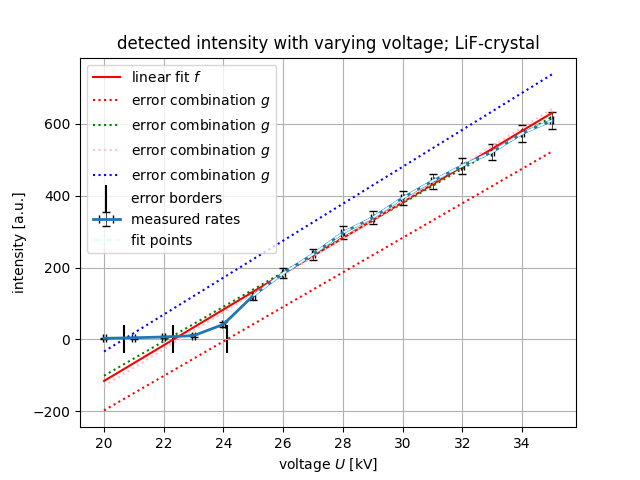

In [361]:
voltage=np.arange(20,36,1)
Delta_voltage=0.05
n=np.array([3.0,4.5,6.75,10.5,41.9,122.0,183.9,237.0,296.9,338.7,393.6,440.5,483.4,521.4,573.1,609.1])
Delta_n=np.sqrt(n)
def linear(x,m,a):
    return m*x+a
popt, pcov=curve_fit(linear, voltage[5:],n[5:],sigma=Delta_n[5:],absolute_sigma=True)
plt.close('all')

plt.errorbar(voltage,n,xerr=Delta_voltage,yerr=Delta_n,fmt='-',linewidth=2,capsize=3,elinewidth=0.5,ecolor='black',label='measured rates')
plt.errorbar(voltage[5:],n[5:],linestyle='dashed',color='lightcyan',ecolor='black',capsize=3,elinewidth=0.5,label='fit points')
plt.plot(np.linspace(20,35,10), linear(np.linspace(20,35,10),*popt),color='red',label=r'linear fit $f$')
m_1=popt[0]-np.sqrt(pcov[0][0])
m_2=popt[0]+np.sqrt(pcov[0][0])
c_1=popt[1]-np.sqrt(pcov[1][1])
c_2=popt[1]+np.sqrt(pcov[1][1])

plt.plot(np.linspace(20,35,10), linear(np.linspace(20,35,10),m_1,c_1),linestyle='dotted',color='red',label=r'error combination $g$')
plt.plot(np.linspace(20,35,10), linear(np.linspace(20,35,10),m_1,c_2),linestyle='dotted',color='green',label=r'error combination $g$')
plt.plot(np.linspace(20,35,10), linear(np.linspace(20,35,10),m_2,c_1),linestyle='dotted',color='pink',label=r'error combination $g$')
plt.plot(np.linspace(20,35,10), linear(np.linspace(20,35,10),m_2,c_2),linestyle='dotted',color='blue',label=r'error combination $g$')
[-c_1/m_1,-c_2/m_2,-popt[1]/popt[0]]
points=[-c_1/m_1,-c_2/m_2,-popt[1]/popt[0]]
plt.scatter(points,[0,0,0],marker='|',s=400,color='black',label='error borders')
U_a=points[2]
Delta_U_a=np.max([points[0]-points[2],points[2]-points[1]])
U_a,Delta_U_a,_,latexUa=round_to_sigs(U_a,Delta_U_a,r'kilo\volt')
print(latexUa)
m=popt[0]
c=popt[1]
Delta_m=np.sqrt(pcov[0][0])
Delta_c=np.sqrt(pcov[1][1])
Delta_U_a= U_a*np.sqrt(Delta_c**2/c**2 + Delta_m**2/m**2)
U_a,Delta_U_a,_,latexUa=round_to_sigs(U_a,Delta_U_a,r'kilo\volt')
print(latexUa)
plt.xlabel(r'voltage $U$ [kV]')
plt.ylabel(r'intensity [a.u.]')
plt.title(r'detected intensity with varying voltage; LiF-crystal')
# plt.text(0.8, 0.2,rf'$E_R={E_R}({Delta_E_R})$keV', horizontalalignment='center',verticalalignment='center', transform=plt.gca().transAxes)
# plt.text(0.8, 0.1,rf'$\sigma_{{12}}={sigma}({Dxelta_sigma})$', horizontalalignment='center',verticalalignment='center', transform=plt.gca().transAxes)
plt.legend()
plt.grid()
plt.show()
plt.savefig(Ausgabe_path/"task3.png",format="png")

In [353]:
critang,Delta_critang=np.radians(7.5),np.radians(0.1)
n=1
d = 201.4*1e-12
critlambda = 2*d*critang / n
Delta_critlambda = 2*d*Delta_critang / n
critlambda,Delta_critlambda,_,latexLcr=round_to_sigs(critlambda,Delta_critlambda,r'\nano\m')
print(latexLcr)

U_a=22.3*1e3
Delta_U_a=1.8*1e3
h=U_a*cc.e*critlambda/cc.c
Delta_h=h*np.sqrt(Delta_U_a**2/U_a**2 + Delta_critlambda**2/critlambda**2)
h,Delta_h,_,latexh=round_to_sigs(h,Delta_h,r'\joule\s')
print(latexh)


\qty{5.27E-11(8E-13)}{\nano\m}
\qty{6.3E-34(6E-35)}{\joule\s}


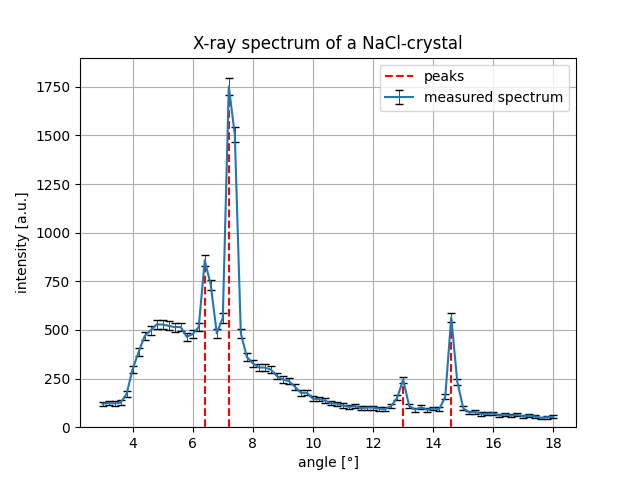

In [360]:
angle,intensity= np.loadtxt(Messwerte_path/"A4_30_06_2026 15_37_32.txt", converters={0:comma_to_float, 1:comma_to_float},unpack=True)
Delta_intensity=np.sqrt(intensity)
peaks_indices,_=scipy.signal.find_peaks(intensity,prominence=150)
peak_angle=np.array(angle[peaks_indices])
# Im Plot markieren (z.B. mit grünen Dreiecken)

plt.close('all')
plt.title(r'X-ray spectrum of a NaCl-crystal')
plt.vlines(peak_angle,ymin=0,ymax=intensity[peaks_indices],linestyle='dashed',color='red',label='peaks')
plt.errorbar(angle,intensity,yerr=Delta_intensity,fmt='-',capsize=3,elinewidth=0.5,ecolor='black',label=r'measured spectrum')
plt.xlabel(r'angle [°]')
plt.ylabel(r'intensity [a.u.]')
plt.ylim(0,1900)
plt.legend() 
plt.grid()
plt.savefig(Ausgabe_path/'task4.png',format="png",bbox_inches='tight')
plt.show()

In [355]:
print(angle[peaks_indices[0]-2:peaks_indices[0]+3])
print(K)
print(Delta_K)

[6.  6.2 6.4 6.6 6.8]
[71.0, 63.0, 71.1, 63.2]
[1.7, 1.7, 1.0, 1.0]


\qty{6.5(0.3)}{\degree}
\num{560(30)}
\qty{7.3(0.4)}{\degree}
\num{560(40)}
\qty{12.92(0.15)}{\degree}
\num{565(12)}
\qty{14.6(0.3)}{\degree}
\num{564(14)}
\qty{562(25)}{\pico\m}


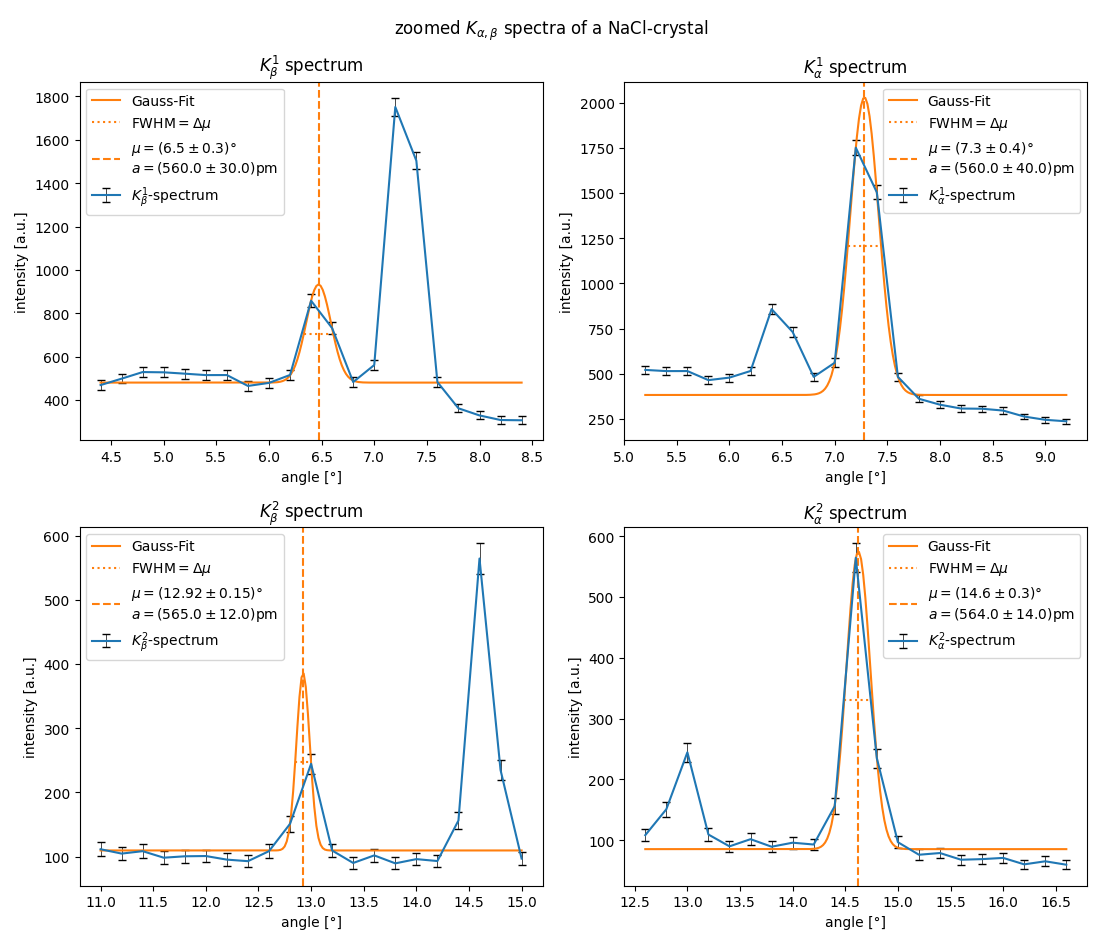

In [356]:
angle,intensity= np.loadtxt(Messwerte_path/"A4_30_06_2026 15_37_32.txt", converters={0:comma_to_float, 1:comma_to_float},unpack=True)
Delta_intensity=np.sqrt(intensity)
peaks_indices,_=scipy.signal.find_peaks(intensity,prominence=150)
peak_angle=np.array(angle[peaks_indices])

peaks=[r"$K^1_\beta$",r"$K^1_\alpha$",r"$K^2_\beta$",r"$K^2_\alpha$"]
K=np.array([63.0,71.0, 63.2, 71.1])
Delta_K=np.array([1.7, 1.7, 1.0, 1.0])

plt.close('all')
fig, axes = plt.subplots(2, 2, figsize=(figsize_cm(14,12)))
fig.suptitle(r'zoomed $K_{\alpha,\beta}$ spectra of a NaCl-crystal')
i=0
aarray=[]
Delta_aarray=[]
for ax,name in zip(axes.flatten(),peaks):
    indices=slice(peaks_indices[i]-10,peaks_indices[i]+11)
    anglearray=np.array(angle[indices])
    intensityarray=np.array(intensity[indices])
    Delta_intensityarray=Delta_intensity[indices]
    ax.errorbar(anglearray,intensityarray,yerr=Delta_intensityarray,fmt='-',capsize=3,elinewidth=0.5,ecolor='black',label=f"{name}-spectrum")

    mu_start=angle[peaks_indices[i]]
    c_start = np.min(intensityarray)                          # Untergrundrauschen
    A_start =(np.max(intensityarray) - c_start)   * (0.1 * np.sqrt(2 * np.pi)) # Fläche rückwärts berechnet
    popt, pcov=curve_fit(gaussian,anglearray,intensityarray,p0=[A_start,mu_start,0.1,c_start],sigma=Delta_intensityarray,absolute_sigma=True)
    x=np.linspace(anglearray[0],anglearray[-1],200)
    ax.plot(x, gaussian(x,*popt), label='Gauss-Fit')

    FHWM=2*popt[2]*np.sqrt(2*np.log(2))
    mu_sig,Delta_mu_sig,_,latexmusig=round_to_sigs(popt[1],FHWM,r'\degree')
    print(latexmusig)
    ax.hlines(1/2*(gaussian(popt[1],*popt)-popt[3])+popt[3],xmin=popt[1]-FHWM/2,xmax=popt[1]+FHWM/2,linestyle='dotted',color='C1',label=r'FWHM$=\Delta \mu$')
    
    ax.set_xlabel(r'angle [°]')
    ax.set_ylabel(r'intensity [a.u.]')
    
    # def deg_to_wavelength(deg,n):
    #     theta_rad = np.radians(deg)
    #     return 2 * d * np.sin(theta_rad)/n
    # def wavelength_to_deg(wl,n):
    # # Arcussinus abfangen, falls Werte außerhalb des Definitionsbereichs liegen
    #     with np.errstate(invalid='ignore'):
    #         return np.degrees(np.arcsin(n*wl / (2 * d)))
    
    n_ord = 1 if popt[1] < 10 else 2
    # Lambda,Delta_lambda,_,latexlambda=round_to_sigs(1e12*deg_to_wavelength(popt[1],n_ord),1e12*(deg_to_wavelength(popt[1]+1/2*FHWM,n_ord)-deg_to_wavelength(popt[1]-1/2*FHWM,n_ord)),r'\pico\m')
    a=n_ord*K[i]/np.sin(np.radians(mu_sig))
    Delta_a=a*np.sqrt(Delta_K[i]**2/K[i]**2 + np.radians(Delta_mu_sig)**2/np.tan(np.radians(mu_sig))**2)
    a,Delta_a,_,latexa=round_to_sigs(a,Delta_a,r'')
    aarray.append(a)
    Delta_aarray.append(Delta_a)
    print(latexa)
    ax.axvline(popt[1],linestyle='--',color='C1',label=rf'$\mu=({mu_sig}\pm{Delta_mu_sig})°$'+'\n'+rf'$a=({a}\pm{Delta_a})$pm')

    # fwd = lambda deg,n=n_ord: deg_to_wavelength(deg, n)
    # inv = lambda wl,n=n_ord: wavelength_to_deg(wl, n)
    # secax = ax.secondary_xaxis('top', functions=(fwd, inv))
    # secax.set_xlabel(r'wavelength $\lambda$ [m]')
    ax.set_title(name+' spectrum')
    ax.legend() 
    i=i+1
a,Delta_a=np.mean(np.array(aarray)),np.sqrt(np.mean(np.array(Delta_aarray))**2+np.std(np.array(aarray))**2)
a,Delta_a,_,latexa=round_to_sigs(a,Delta_a,r'\pico\m')
print(latexa)
plt.tight_layout()
plt.savefig(Ausgabe_path/'KlinesNaCl.png',format="png",bbox_inches='tight')
plt.show()

In [357]:
M=58.44
rho=2.164/(100**3)
N_A=4*M/(a**3*rho)/(1e-2)**12*1e-23
Delta_N_A=N_A*3*sqrt(Delta_a**2/a**2)
N_A,Delta_N_A,_,latexNA=round_to_sigs(N_A,Delta_N_A,r'\1e23\per\mole')
print(latexNA)

M=25.94
rho=2.635/(100**3)
a=201.4*2
N_A=4*M/(a**3*rho)/(1e-2)**12*1e-23
print(N_A)


\qty{6.1(0.9)}{\1e23\per\mole}
6.025331667684615


In [358]:
compare_table_array(r'h_\theta',r'h_\text{Lit}',r'\joule\s',[6.5,6.3],[1.5,0.6],[6.62607015,6.62607015],[0,0])
K_alpha,Delta_K_alpha,_,_=round_to_sigs(np.mean([71.0,71.1]),np.sqrt(np.mean([1.7,1.0])**2+np.std([71.0,71.1])**2),r'')
K_beta,Delta_K_beta,_,_=round_to_sigs(np.mean([63.0,63.2]),np.sqrt(np.mean([1.7,1.0])**2+np.std([63.0,63.3])**2),r'')
compare_table_array(r'K^\text{exp}_\alpha(Mo)',r'K^\text{Lit}_\alpha(Mo)',r'\pico\m',[K_alpha,K_beta],[Delta_K_alpha,Delta_K_beta],[71.1,63.1],[0,0])
compare_table(r'N_A^text{exp}',r'N_A^\text{lit}',r'\per\mole',6.1,0.9,6.02214076,0)

\begin{table}[htbp]
\centering
\caption{Vergleich von $h_\theta$ und $h_\text{Lit}$}
\begin{tabularx}{0.8\textwidth}{ZZZZZ}
    \toprule
         Messreihe & h_\theta[\unit{\joule\s}] & h_\text{Lit}[\unit{\joule\s}] & \text{abs.Abw.}[\unit{\joule\s}] & \text{proz.Abw.}[\unit{\percent}] & S[\sigma] \\\midrule
        & \num{6.5(1.5)} & 6.62607015 & \num{0.1(1.5)} & \num{2(24)} & \num{0.09} \\
        & \num{6.3(0.6)} & 6.62607015 & \num{0.3(0.6)} & \num{5(10)} & \num{0.6} \\
\bottomrule
\end{tabularx}
\label{table:Vergleich_h_\theta} 
\end{table}
\begin{table}[htbp]
\centering
\caption{Vergleich von $K^\text{exp}_\alpha(Mo)$ und $K^\text{Lit}_\alpha(Mo)$}
\begin{tabularx}{0.8\textwidth}{ZZZZZ}
    \toprule
         Messreihe & K^\text{exp}_\alpha(Mo)[\unit{\pico\m}] & K^\text{Lit}_\alpha(Mo)[\unit{\pico\m}] & \text{abs.Abw.}[\unit{\pico\m}] & \text{proz.Abw.}[\unit{\percent}] & S[\sigma] \\\midrule
        & \num{71.1(1.4)} & 71.1 & 0 & 0 & \num{0} \\
        & \num{63.1(1.4)} & 63.1 & 

In [359]:
gff("4*M/(rho*d**3)","d")

Funktion:


<IPython.core.display.Math object>

\frac{4 M}{d^{3} \rho}
Absoluter Fehler:


<IPython.core.display.Math object>

12 \sqrt{\frac{\Delta_{d}^{2} M^{2}}{d^{8} \rho^{2}}}
Relativer Fehler:


<IPython.core.display.Math object>

3 \sqrt{\frac{\Delta_{d}^{2}}{d^{2}}}


(4*M/(d**3*rho),
 12*sqrt(Delta_d**2*M**2/(d**8*rho**2)),
 3*sqrt(Delta_d**2/d**2),
 [(d, Delta_d)])